## Libraries

In [81]:
import numpy as np
#from scipy.signal import lfilter, firwin
from pylab import *
from scipy.fftpack import fft,fftshift
import scipy.signal as signal
from tool._fixedInt import *
from scipy.signal import lfilter


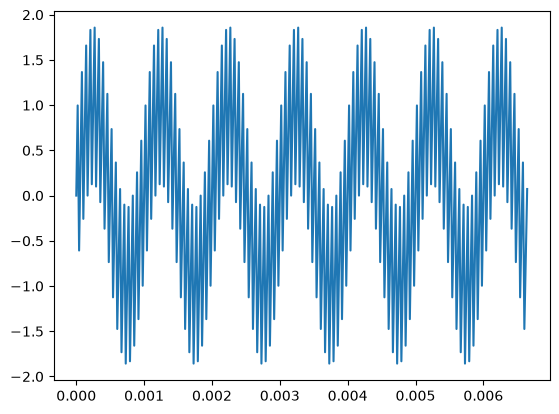

In [82]:
fs = 48000.
nsamples = 320

F_1KHz = 1000.
A_1KHz = 1.0
 
F_15KHz = 16000.
A_15KHz = 1
 
t = np.arange(nsamples) / fs

noise  = A_15KHz * np.sin(2*np.pi*F_15KHz*t)
perfect_signal = A_1KHz  * np.sin(2*np.pi*F_1KHz*t)
signal_gen = perfect_signal + noise

plt.plot(t, signal_gen)

In [83]:
fir_coeff = np.array([0.25, 0.5, 0.5, 0.25])




coeff = arrayFixedInt(16,15,fir_coeff)


In [84]:
b_q   = [a.fValue for a in coeff]      # es tu value_coeff

w, H   = signal.freqz(fir_coeff, a=1, worN=1024, fs=fs)   # ideal (float)
wq, Hq = signal.freqz(b_q,       a=1, worN=1024, fs=fs)   # con coeficientes S(8,7)

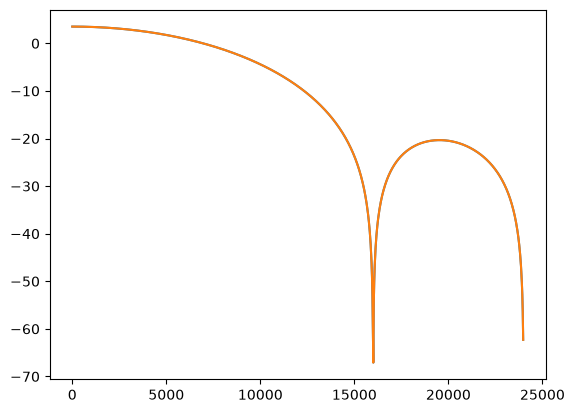

In [ ]:
plt.plot(wq, 20 * np.log10(np.abs(Hq)+1e-20))
plt.plot(w,  20 * np.log10(np.abs(H)+1e-20))
# da igual la representacion, por que esos coeficientes se pueden representar perfectamente con pocos bits

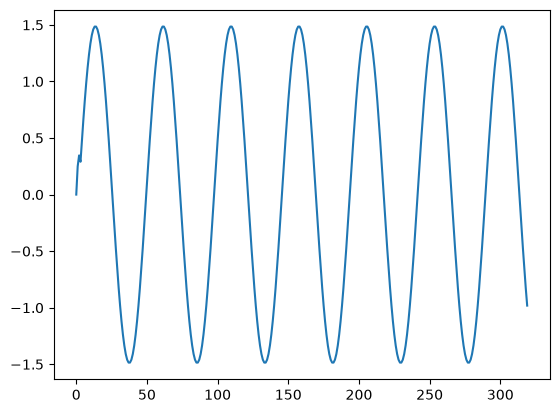

In [86]:
y = lfilter(fir_coeff, 1.0, signal_gen)

plt.plot(y)